# STAGE 1 - DATA LOADING AND PREPROCESSING

In [21]:
# dataset
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shubhambathwal/flight-price-prediction")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'flight-price-prediction' dataset.
Path to dataset files: /kaggle/input/flight-price-prediction


In [74]:
# import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns



In [23]:
# view data
data=pd.read_csv(path+"/Clean_Dataset.csv")
data.head()

,Unnamed: 0,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price
0,0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953
1,1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953
2,2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956
3,3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955
4,4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955


In [24]:
economy = pd.read_csv(path+"/economy.csv")
economy.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,SpiceJet,SG,8709,18:55,Delhi,02h 10m,non-stop,21:05,Mumbai,"5,953"
1,11-02-2022,SpiceJet,SG,8157,06:20,Delhi,02h 20m,non-stop,08:40,Mumbai,"5,953"
2,11-02-2022,AirAsia,I5,764,04:25,Delhi,02h 10m,non-stop,06:35,Mumbai,"5,956"
3,11-02-2022,Vistara,UK,995,10:20,Delhi,02h 15m,non-stop,12:35,Mumbai,"5,955"
4,11-02-2022,Vistara,UK,963,08:50,Delhi,02h 20m,non-stop,11:10,Mumbai,"5,955"


In [25]:
business = pd.read_csv(path+"/business.csv")
business.head()

,date,airline,ch_code,num_code,dep_time,from,time_taken,stop,arr_time,to,price
0,11-02-2022,Air India,AI,868,18:00,Delhi,02h 00m,non-stop,20:00,Mumbai,"25,612"
1,11-02-2022,Air India,AI,624,19:00,Delhi,02h 15m,non-stop,21:15,Mumbai,"25,612"
2,11-02-2022,Air India,AI,531,20:00,Delhi,24h 45m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,20:45,Mumbai,"42,220"
3,11-02-2022,Air India,AI,839,21:25,Delhi,26h 30m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"44,450"
4,11-02-2022,Air India,AI,544,17:15,Delhi,06h 40m,1-stop\n\t\t\t\t\t\t\t\t\t\t\t\t\n\t\t\t\t\t\t...,23:55,Mumbai,"46,690"


In [26]:
# check for duplicates
data.duplicated().sum()

np.int64(0)

In [27]:
data.isnull().sum()

,0
Unnamed: 0,0
airline,0
flight,0
source_city,0
departure_time,0
stops,0
arrival_time,0
destination_city,0
class,0
duration,0


In [28]:
data.shape

(300153, 12)

In [29]:
# Count of the airlines
data['airline'].value_counts()

,count
airline,
Vistara,127859
Air_India,80892
Indigo,43120
GO_FIRST,23173
AirAsia,16098
SpiceJet,9011


In [30]:
data.describe()

,Unnamed: 0,duration,days_left,price
count,300153.000000,300153.000000,300153.000000,300153.000000
mean,150076.000000,12.221021,26.004751,20889.660523
std,86646.852011,7.191997,13.561004,22697.767366
min,0.000000,0.830000,1.000000,1105.000000
25%,75038.000000,6.830000,15.000000,4783.000000
50%,150076.000000,11.250000,26.000000,7425.000000
75%,225114.000000,16.170000,38.000000,42521.000000
max,300152.000000,49.830000,49.000000,123071.000000


In [31]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 300153 entries, 0 to 300152
Data columns (total 12 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        300153 non-null  int64  
 1   airline           300153 non-null  object 
 2   flight            300153 non-null  object 
 3   source_city       300153 non-null  object 
 4   departure_time    300153 non-null  object 
 5   stops             300153 non-null  object 
 6   arrival_time      300153 non-null  object 
 7   destination_city  300153 non-null  object 
 8   class             300153 non-null  object 
 9   duration          300153 non-null  float64
 10  days_left         300153 non-null  int64  
 11  price             300153 non-null  int64  
dtypes: float64(1), int64(3), object(8)
memory usage: 27.5+ MB


In [32]:
print(f"Price Range: {max(data['price'])} to {min(data['price'])}")
print("Average Price",data['price'].mean().round(3))

Price Range: 123071 to 1105
Average Price 20889.661


In [33]:
# create a new route column
data['route']=data['source_city']+"->"+data['destination_city']

In [34]:
data['route'].value_counts()

,count
route,
Delhi->Mumbai,15289
Mumbai->Delhi,14809
Delhi->Bangalore,14012
Bangalore->Delhi,13756
Bangalore->Mumbai,12939
Mumbai->Bangalore,12885
Mumbai->Kolkata,12602
Delhi->Kolkata,11934
Kolkata->Mumbai,11467


In [35]:
# class distribution
data['class'].value_counts()

,count
class,
Economy,206666
Business,93487


In [36]:
# stop distribution
data['stops'].value_counts()

,count
stops,
one,250863
zero,36004
two_or_more,13286


In [37]:
data=data.drop(['Unnamed: 0'],axis=1)

In [38]:
data.head()

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,route
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,Delhi->Mumbai
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,Delhi->Mumbai
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,Delhi->Mumbai
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,Delhi->Mumbai
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,Delhi->Mumbai


In [39]:
data.to_csv("flight_prices_clean_data.csv",index=False)
print("saved successfully")

saved successfully


# STAGE 2 - SQL ANALYSIS

In [40]:

# connect to sql
import sqlite3 as sql
conn=sql.connect('flights.db')
data.to_sql('flights', conn, if_exists='replace', index=False)
res=pd.read_sql_query("SELECT COUNT(*) as total FROM flights",conn)
print(res)

    total
0  300153


In [41]:
result = pd.read_sql_query("SELECT * FROM flights LIMIT 5", conn)
result

,airline,flight,source_city,departure_time,stops,arrival_time,destination_city,class,duration,days_left,price,route
0,SpiceJet,SG-8709,Delhi,Evening,zero,Night,Mumbai,Economy,2.17,1,5953,Delhi->Mumbai
1,SpiceJet,SG-8157,Delhi,Early_Morning,zero,Morning,Mumbai,Economy,2.33,1,5953,Delhi->Mumbai
2,AirAsia,I5-764,Delhi,Early_Morning,zero,Early_Morning,Mumbai,Economy,2.17,1,5956,Delhi->Mumbai
3,Vistara,UK-995,Delhi,Morning,zero,Afternoon,Mumbai,Economy,2.25,1,5955,Delhi->Mumbai
4,Vistara,UK-963,Delhi,Morning,zero,Morning,Mumbai,Economy,2.33,1,5955,Delhi->Mumbai


In [73]:
# ============================================
#  Q1: Which airline is cheapest overall?
#  Business Question: As a traveler, which airline
#  should I choose to minimize my ticket cost?
#  ============================================
res1 = pd.read_sql_query(
    """SELECT airline,
    MIN(price) AS min_price,
    MAX(price) AS max_price,
    ROUND(AVG(price),2) AS avg_price
    FROM flights
    GROUP BY airline
    ORDER BY avg_price ASC""",
    conn
)
print(res1)

     airline  min_price  max_price  avg_price
0    AirAsia       1105      31917    4091.07
1     Indigo       1105      31952    5324.22
2   GO_FIRST       1105      32803    5652.01
3   SpiceJet       1106      34158    6179.28
4  Air_India       1526      90970   23507.02
5    Vistara       1714     123071   30396.54


In [72]:
# ============================================
# Q2: Which airline is cheapest for Economy vs Business separately?
# ============================================
res2=pd.read_sql_query(
   """SELECT airline,
   class,
   MIN(price) AS min_price,
   MAX(price) AS max_price,
   ROUND(AVG(price),2) AS avg_price,
   COUNT(*) AS total_flights
   FROM flights
   GROUP BY airline, class
   ORDER BY avg_price ASC""",conn
)
res2

,airline,class,min_price,max_price,avg_price,total_flights
0,AirAsia,Economy,1105,31917,4091.07,16098
1,Indigo,Economy,1105,31952,5324.22,43120
2,GO_FIRST,Economy,1105,32803,5652.01,23173
3,SpiceJet,Economy,1106,34158,6179.28,9011
4,Air_India,Economy,1526,42349,7313.68,47994
5,Vistara,Economy,1714,37646,7806.94,67270
6,Air_India,Business,12000,90970,47131.04,32898
7,Vistara,Business,17604,123071,55477.03,60589


In [71]:
# ============================================
# Q3: How many days before departure should you book for cheapest price?
# Business Question: When is the best time to book to get cheapest fare?
# ============================================
res3=pd.read_sql_query(
    """SELECT
    days_left ,
    ROUND(AVG(price)) AS avg_price ,
    MIN(price) AS min_price ,
    COUNT(*) AS total_flights
    FROM flights
    GROUP BY days_left
    ORDER BY AVG_PRICE ASC
    """,conn

)
res3



,days_left,avg_price,min_price,total_flights
0,47,18553.0,1105,6069
1,49,18993.0,1105,6154
2,48,18998.0,1105,6078
3,44,19049.0,1105,6436
4,40,19145.0,1105,6531
5,42,19154.0,1105,6497
6,45,19200.0,1105,6314
7,26,19238.0,1105,6573
8,35,19256.0,1105,6291
9,32,19258.0,1105,6585


In [70]:
# ============================================
# Q4: Which departure time slot gives cheapest prices?
# Business Question: Should I book morning or evening flights to save money?
# ============================================
res4=pd.read_sql_query(
    """SELECT
    departure_time ,
    ROUND(AVG(price),2) AS avg_price,
    MIN(price) AS min_price ,
    COUNT(*) AS total_flights
    FROM flights
    GROUP BY departure_time
    ORDER BY avg_price ASC""",conn
)
res4

,departure_time,avg_price,min_price,total_flights
0,Late_Night,9295.30,2050,1306
1,Afternoon,18179.20,1105,47794
2,Early_Morning,20370.68,1105,66790
3,Evening,21232.36,1105,65102
4,Morning,21630.76,1105,71146
5,Night,23062.15,1105,48015


In [69]:
# ============================================
# Q5: Does booking non-stop vs 1-stop actually save money?
# Business Question: Is it worth taking a connecting flight to save money?
# ============================================
res5=pd.read_sql_query(
    """SELECT
    stops,
    ROUND(AVG(price),2) AS avg_price,
    MIN(price) AS min_price
    FROM flights
    GROUP BY stops
    ORDER BY avg_price""",conn
)
res5

,stops,avg_price,min_price
0,zero,9375.94,1105
1,two_or_more,14113.45,1966
2,one,22900.99,1105


In [68]:
# ============================================
# Q6: What is avg, min, max price for each route?
# Business Question: Which routes are expensive and which are budget friendly?
# ============================================
res6=pd.read_sql_query(
    """SELECT
    route ,
    ROUND(AVG(price),2) AS avg_price,
    MIN(price) AS min_price,
    MAX(price) AS max_price
    FROM flights
    GROUP BY route
    ORDER BY avg_price ASC""",conn

)
res6

,route,avg_price,min_price,max_price
0,Hyderabad->Delhi,17243.95,2200,86203
1,Delhi->Hyderabad,17347.29,2022,114507
2,Bangalore->Delhi,17723.31,2723,111883
3,Delhi->Bangalore,17880.22,3090,85353
4,Mumbai->Delhi,18725.32,2336,111437
5,Chennai->Delhi,18981.86,2051,103683
6,Delhi->Mumbai,19355.83,2281,95657
7,Delhi->Chennai,19369.88,1998,104466
8,Kolkata->Delhi,19422.35,2994,123071
9,Hyderabad->Mumbai,20080.87,2250,115211


In [67]:
# ============================================
# Q7: Which is the cheapest airline for each route?
# Business Question: For my specific route, which airline should I pick?
# ============================================

res7=pd.read_sql_query(
    """SELECT
    t1.route,
    t1.airline,
    t1.avg_price
FROM (
    SELECT
        route,
        airline,
        ROUND(AVG(price), 2) AS avg_price
    FROM flights
    WHERE class='Economy'
    GROUP BY route, airline
) AS t1
JOIN (
    SELECT
        route,
        MIN(avg_price_per_airline) AS min_avg_price
    FROM (
        SELECT
            route,
            airline,
            ROUND(AVG(price), 2) AS avg_price_per_airline
        FROM flights
        WHERE class='Economy'
        GROUP BY route, airline
    ) AS sub_t2
    GROUP BY route
) AS t2
ON t1.route = t2.route AND t1.avg_price = t2.min_avg_price
ORDER BY t1.route, t1.avg_price ASC""",conn
)
res7

,route,airline,avg_price
0,Bangalore->Chennai,AirAsia,2073.04
1,Bangalore->Delhi,AirAsia,4807.09
2,Bangalore->Hyderabad,AirAsia,2931.49
3,Bangalore->Kolkata,AirAsia,4443.47
4,Bangalore->Mumbai,AirAsia,3342.39
5,Chennai->Bangalore,AirAsia,1914.76
6,Chennai->Delhi,AirAsia,3697.31
7,Chennai->Hyderabad,GO_FIRST,1613.11
8,Chennai->Kolkata,AirAsia,3682.34
9,Chennai->Mumbai,AirAsia,2691.10


In [66]:
# ============================================
# Q8: Cheapest flight on Delhi to Mumbai route
# Business Question: I need to fly Delhi to Mumbai, what's my cheapest option?
# ============================================
res8=pd.read_sql_query(
    """SELECT
        airline,
        departure_time,
        stops,
        days_left,
        price
    FROM flights
    WHERE route='Delhi->Mumbai'
    AND class='Economy'
    ORDER BY price ASC
    LIMIT 5;""",conn)
res8

,airline,departure_time,stops,days_left,price
0,SpiceJet,Morning,zero,47,2281
1,SpiceJet,Early_Morning,zero,47,2281
2,SpiceJet,Evening,zero,47,2281
3,SpiceJet,Evening,zero,47,2281
4,Indigo,Evening,one,46,2381


In [64]:
# ============================================
# Q9: Which route has biggest price gap between Economy and Business?
# Business Question: Where is upgrading to Business most and least worth it?
# ============================================
res9=pd.read_sql_query(
    """SELECT
    route ,
    ROUND(AVG(CASE WHEN class = 'Economy' THEN price END), 0) AS economy_avg,
    ROUND(AVG(CASE WHEN class = 'Business' THEN price END), 0) AS business_avg,
    ROUND(AVG(CASE WHEN class = 'Business' THEN price END) -
              AVG(CASE WHEN class = 'Economy' THEN price END), 0) AS price_gap
    FROM flights
    GROUP BY route
    ORDER BY price_gap DESC """,
    conn
)
res9

,route,economy_avg,business_avg,price_gap
0,Bangalore->Mumbai,6381.0,58025.0,51644.0
1,Mumbai->Bangalore,6433.0,57971.0,51538.0
2,Bangalore->Kolkata,7376.0,58855.0,51479.0
3,Kolkata->Bangalore,7472.0,58681.0,51209.0
4,Kolkata->Mumbai,7406.0,57423.0,50017.0
5,Mumbai->Kolkata,7228.0,57107.0,49879.0
6,Chennai->Mumbai,6529.0,56224.0,49695.0
7,Chennai->Kolkata,7547.0,57079.0,49532.0
8,Mumbai->Chennai,6421.0,55703.0,49282.0
9,Delhi->Kolkata,7046.0,56240.0,49194.0


In [63]:
# ============================================
# Q10: Which airline dominates most routes?
# Business Question: Which airline has the widest network coverage?
# ============================================
res10=pd.read_sql_query(
    """SELECT
    airline ,
    COUNT(route) AS total_routes
    FROM flights
    GROUP BY airline
    ORDER BY total_routes DESC""",conn
)
res10

,airline,total_routes
0,Vistara,127859
1,Air_India,80892
2,Indigo,43120
3,GO_FIRST,23173
4,AirAsia,16098
5,SpiceJet,9011


In [62]:
# ============================================
# Q11: Which destination is cheapest to fly to from any city?
# Business Question: Where should I fly if I want the cheapest destination?
# ============================================

res11 = pd.read_sql_query("""
    SELECT
        destination_city,
        ROUND(AVG(price), 0) AS avg_price,
        MIN(price) AS min_price,
        COUNT(*) AS total_flights
    FROM flights
    WHERE class = 'Economy'
    GROUP BY destination_city
    ORDER BY avg_price ASC
""", conn)

res11

,destination_city,avg_price,min_price,total_flights
0,Delhi,6251.0,2051,40653
1,Hyderabad,6306.0,1105,29051
2,Mumbai,6460.0,1830,40106
3,Bangalore,6618.0,1443,34870
4,Chennai,6642.0,1543,27210
5,Kolkata,7201.0,2056,34776


In [61]:
# ============================================
# Q12: Price by departure time AND airline combined
# Business Question: Which airline at which time gives the cheapest fare?
# ============================================

res12 = pd.read_sql_query("""
    SELECT
        airline,
        departure_time,
        ROUND(AVG(price), 0) AS avg_price,
        COUNT(*) AS total_flights
    FROM flights
    WHERE class = 'Economy'
    GROUP BY airline, departure_time
    ORDER BY avg_price ASC
    LIMIT 15
""", conn)

res12

,airline,departure_time,avg_price,total_flights
0,AirAsia,Night,3344.0,3180
1,AirAsia,Evening,4059.0,3657
2,AirAsia,Morning,4133.0,2348
3,AirAsia,Late_Night,4183.0,143
4,Indigo,Late_Night,4317.0,726
5,Indigo,Night,4324.0,4104
6,AirAsia,Afternoon,4343.0,3078
7,AirAsia,Early_Morning,4527.0,3692
8,GO_FIRST,Late_Night,4807.0,146
9,Indigo,Evening,4814.0,8460


# STAGE 3 - PYTHON VISUALIZATION

In [88]:
sns.set_style("whitegrid")
sns.set_palette("viridis")

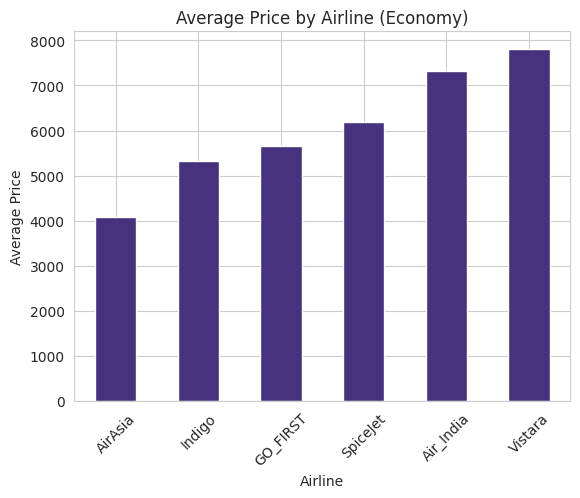

In [89]:
# =====================================
# BAR CHART - cheapest airline
# =====================================
avg_price_airline = data[data['class']=='Economy'].groupby('airline')['price'].mean().sort_values()

plt.figure()
avg_price_airline.plot(kind='bar')
plt.title("Average Price by Airline (Economy)")
plt.xlabel("Airline")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

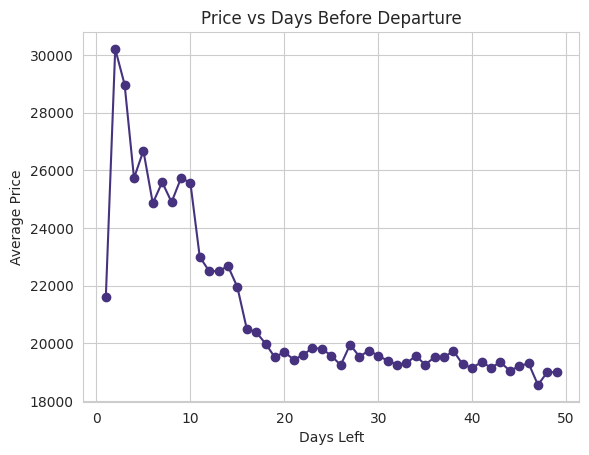

In [90]:
# =====================================
# LINE CHART - prices vs days before departure
# =====================================
price_trend = data.groupby('days_left')['price'].mean()

plt.figure()
price_trend.plot( marker='o')
plt.title("Price vs Days Before Departure")
plt.xlabel("Days Left")
plt.ylabel("Average Price")
plt.show()

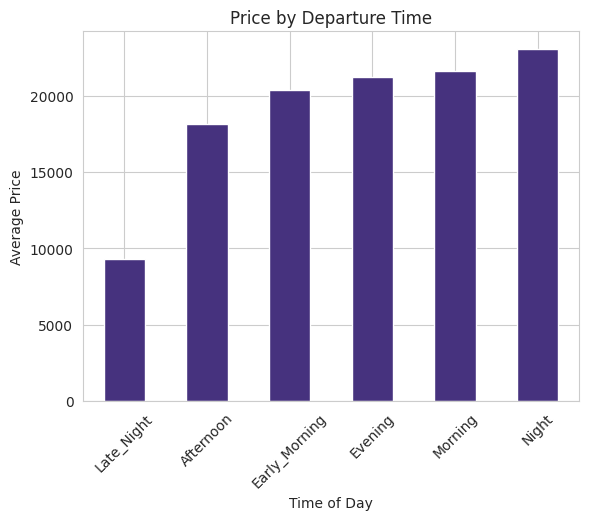

In [92]:
# =====================================
# BAR CHART - prices by departure time
# =====================================
time_price = data.groupby('departure_time')['price'].mean().sort_values()

plt.figure()
time_price.plot(kind='bar')
plt.title("Price by Departure Time")
plt.xlabel("Time of Day")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

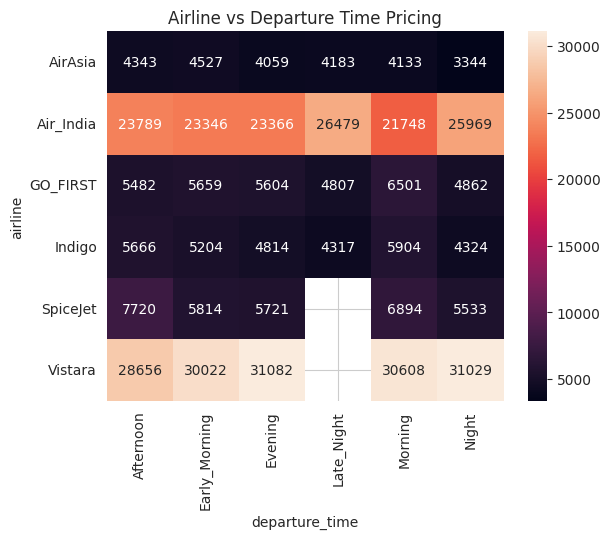

In [93]:
# =====================================
# HEATMAP - airline vs departure time
# =====================================
pivot = data.pivot_table(
    values='price',
    index='airline',
    columns='departure_time',
    aggfunc='mean'
)

plt.figure()
sns.heatmap(pivot, annot=True, fmt=".0f")
plt.title("Airline vs Departure Time Pricing")
plt.show()

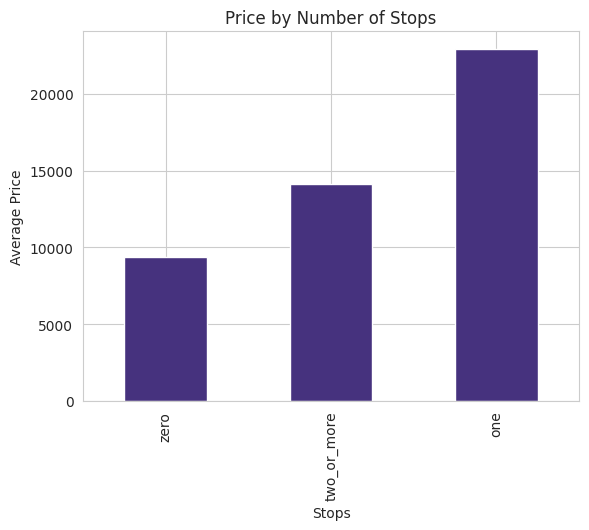

In [94]:
# =====================================
# BARCHART - prices vs stops
# =====================================
stops_price = data.groupby('stops')['price'].mean().sort_values()

plt.figure()
stops_price.plot(kind='bar')
plt.title("Price by Number of Stops")
plt.xlabel("Stops")
plt.ylabel("Average Price")
plt.show()

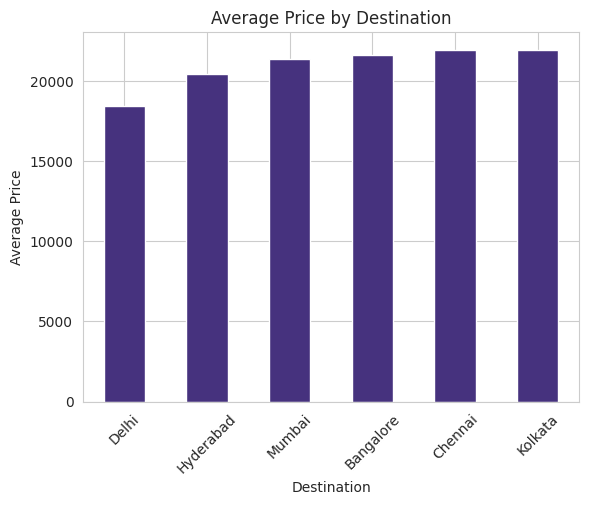

In [95]:
# =====================================
# BARCHART - cheapest destination
# =====================================
dest_price = data.groupby('destination_city')['price'].mean().sort_values()

plt.figure()
dest_price.plot(kind='bar')
plt.title("Average Price by Destination")
plt.xlabel("Destination")
plt.ylabel("Average Price")
plt.xticks(rotation=45)
plt.show()

# STAGE 4 - ML MODEL

In [96]:
# Select Features
features = ['airline', 'source_city', 'destination_city',
            'days_left', 'departure_time', 'stops', 'class']

target = 'price'

In [97]:
# convert to numerical form
data_encoded = pd.get_dummies(data[features], drop_first=True)

In [99]:
# train test split
from sklearn.model_selection import train_test_split

X = data_encoded
y = data[target]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [100]:
# model
from sklearn.ensemble import RandomForestRegressor

model = RandomForestRegressor(n_estimators=100, random_state=42)

model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [101]:
# predictions
y_pred = model.predict(X_test)

In [102]:
# evaluation
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R2 Score:", r2)

RMSE: 4530.637829955887
R2 Score: 0.9601796604874234


In [103]:
# sample prediction
sample = pd.DataFrame({
    'airline': ['IndiGo'],
    'source_city': ['Delhi'],
    'destination_city': ['Mumbai'],
    'days_left': [20],
    'departure_time': ['Morning'],
    'stops': ['zero'],
    'class': ['Economy']
})

sample_encoded = pd.get_dummies(sample)
sample_encoded = sample_encoded.reindex(columns=X.columns, fill_value=0)

prediction = model.predict(sample_encoded)

print("Predicted Price:", prediction[0])

Predicted Price: 2536.2457738095236


In [104]:
# feature importance
import pandas as pd

importance = pd.Series(model.feature_importances_, index=X.columns)
importance.sort_values(ascending=False).head(10)

,0
class_Economy,0.900366
stops_zero,0.037812
days_left,0.020265
airline_Air_India,0.005665
airline_Vistara,0.005238
destination_city_Delhi,0.004251
source_city_Delhi,0.004143
source_city_Mumbai,0.002593
destination_city_Mumbai,0.002251
source_city_Kolkata,0.002149


# STAGE 5

In [106]:
import pickle

pickle.dump(model, open("model.pkl", "wb"))
pickle.dump(X.columns, open("model_columns.pkl", "wb"))

In [108]:
from google.colab import files

files.download('model.pkl')

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [107]:
import pickle

# Load the model
loaded_model = pickle.load(open('model.pkl', 'rb'))
print("Contents of model.pkl (Loaded Model):\n")
print(loaded_model)

# Load the column names
loaded_columns = pickle.load(open('model_columns.pkl', 'rb'))
print("\nContents of model_columns.pkl (Loaded Columns):\n")
print(loaded_columns)

Contents of model.pkl (Loaded Model):

RandomForestRegressor(random_state=42)

Contents of model_columns.pkl (Loaded Columns):

Index(['days_left', 'airline_Air_India', 'airline_GO_FIRST', 'airline_Indigo',
       'airline_SpiceJet', 'airline_Vistara', 'source_city_Chennai',
       'source_city_Delhi', 'source_city_Hyderabad', 'source_city_Kolkata',
       'source_city_Mumbai', 'destination_city_Chennai',
       'destination_city_Delhi', 'destination_city_Hyderabad',
       'destination_city_Kolkata', 'destination_city_Mumbai',
       'departure_time_Early_Morning', 'departure_time_Evening',
       'departure_time_Late_Night', 'departure_time_Morning',
       'departure_time_Night', 'stops_two_or_more', 'stops_zero',
       'class_Economy'],
      dtype='object')
